Downloading the model

In [3]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
# model_ckpt = "google/pegasus-x-base"
# tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
# model_pegasus = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

In [4]:
from datasets import load_dataset
import pandas as pd

In [5]:
dataset = load_dataset("samsum", trust_remote_code=True)

In [6]:
dataset["train"][:5]

{'id': ['13818513', '13728867', '13681000', '13730747', '13728094'],
 'dialogue': ["Amanda: I baked  cookies. Do you want some?\r\nJerry: Sure!\r\nAmanda: I'll bring you tomorrow :-)",
  'Olivia: Who are you voting for in this election? \r\nOliver: Liberals as always.\r\nOlivia: Me too!!\r\nOliver: Great',
  "Tim: Hi, what's up?\r\nKim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating\r\nTim: What did you plan on doing?\r\nKim: Oh you know, uni stuff and unfucking my room\r\nKim: Maybe tomorrow I'll move my ass and do everything\r\nKim: We were going to defrost a fridge so instead of shopping I'll eat some defrosted veggies\r\nTim: For doing stuff I recommend Pomodoro technique where u use breaks for doing chores\r\nTim: It really helps\r\nKim: thanks, maybe I'll do that\r\nTim: I also like using post-its in kaban style",
  "Edward: Rachel, I think I'm in ove with Bella..\r\nrachel: Dont say anything else..\r\nEdward: What do you mean??\r\nrachel: Open your fu

array([[<Axes: title={'center': 'Dialogue Length'}>,
        <Axes: title={'center': 'Summary Length'}>]], dtype=object)

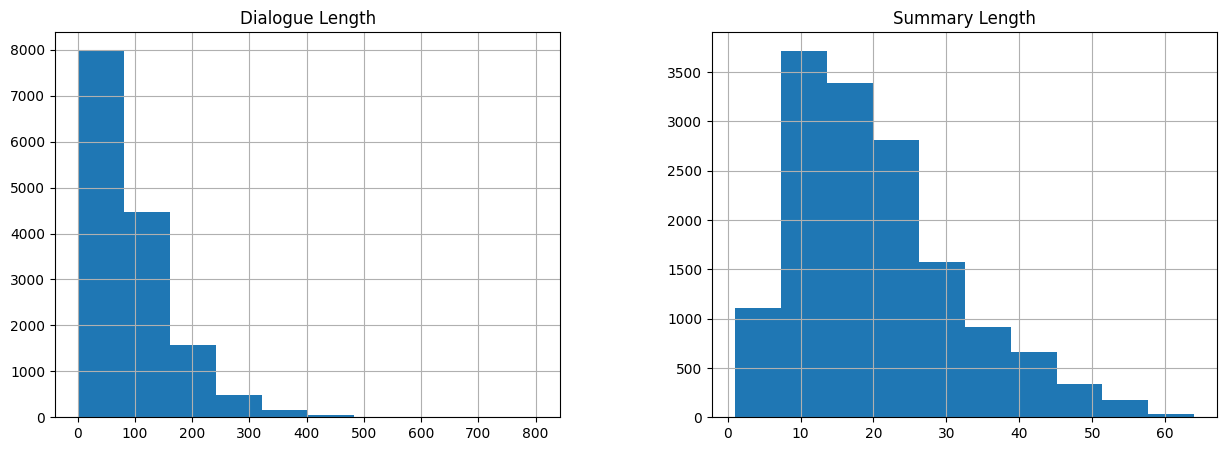

In [7]:
import matplotlib.pyplot as plt
dialogue_len = [len(x['dialogue'].split()) for x in dataset['train']]
summary_len = [len(x['summary'].split()) for x in dataset['train']]

data = pd.DataFrame([dialogue_len, summary_len]).T
data.columns = ['Dialogue Length', 'Summary Length']

data.hist(figsize=(15,5))

In [8]:
from transformers import pipeline, set_seed

import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

In [9]:
def preprocess_function(example_batch):

    encodings = tokenizer(example_batch['dialogue'], text_target=example_batch['summary'],
                        max_length=1024, truncation=True)

    encodings = {'input_ids': encodings['input_ids'],
               'attention_mask': encodings['attention_mask'],
               'labels': encodings['labels']}

    return encodings

In [10]:
samsum_tokenize_pt = dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 818/818 [00:00<00:00, 2006.98 examples/s]


In [11]:
columns = ['input_ids', 'labels', 'attention_mask']
samsum_tokenize_pt.set_format(type='torch', columns=columns)

In [12]:
from transformers import DataCollatorForSeq2Seq
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model_pegasus)

In [13]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir = 'pegasus-samsum',
    num_train_epochs=10,
    warmup_steps = 500,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    weight_decay = 0.01,
    logging_steps = 10,
    evaluation_strategy = 'steps',
    eval_steps=500,
    save_steps=1e6,
    gradient_accumulation_steps=16
)

c:\Users\kshubhan\.conda\envs\pegasus\Lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer = Trainer(model=model_pegasus, args=training_args, tokenizer=tokenizer, data_collator=data_collator, train_dataset = samsum_tokenize_pt['train'], eval_dataset = samsum_tokenize_pt['validation'])

C:\Users\kshubhan\AppData\Local\Temp\ipykernel_52376\949096357.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model_pegasus, args=training_args, tokenizer=tokenizer, data_collator=data_collator, train_dataset = samsum_tokenize_pt['train'], eval_dataset = samsum_tokenize_pt['validation'])


: 

In [ ]:
trainer.train()

c:\Users\kshubhan\.conda\envs\pegasus\Lib\site-packages\transformers\data\data_collator.py:657: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Step,Training Loss,Validation Loss
